In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [117]:
path = "../dataset/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
df = pd.read_csv(path)

In [118]:
# Compute derived columns
df['arrival_time'] = df['end_timestamp'] - df['duration']
df.sort_values(by='arrival_time', inplace=True)
hour_trace = 4
df['trace_id'] = (df['arrival_time'] // (hour_trace * 3600)).astype(int)
df['arrival_time_norm'] = df['arrival_time'] - (df['trace_id'] * hour_trace * 3600)


In [119]:
# #Define categories
# categories = [
#     (40, 70, 2),     # Category 1: long tasks
#     (80, 150, 2),    # Category 2: medium tasks
#     (151, 250, 3)    # Category 3: shorter tasks
# ]

In [120]:
min_gap = 600  # 10 minutes between requests
best_groups = []
selected_funcs = set()

# Define categories: (min_requests, max_requests, num_functions)
categories = [
    (30, 60, 2),    # Category 1: 2 functions, 50-80 requests
    (70, 150, 2),  # Category 2: 2 functions, 100-150 requests
    (180, 220, 3)   # Category 3: 3 functions, 300-500 requests
]

# Loop over categories
for cat_idx, (min_req, max_req, num_func) in enumerate(categories):
    best_score = -1
    best_group = None

    # Iterate over each trace ID
    for trace_id in df['trace_id'].unique():
        trace = df[df['trace_id'] == trace_id]
        func_counts = trace['func'].value_counts()

        # Filter candidate functions within request range
        candidate_funcs = func_counts[
            (func_counts >= min_req) & (func_counts <= max_req)
        ].index.difference(selected_funcs).tolist()

        if len(candidate_funcs) < num_func:
            continue

        # Test all combinations of candidate functions
        for funcs in combinations(candidate_funcs, num_func):
            gap_ratios = []
            for f in funcs:
                times = trace[trace['func'] == f]['arrival_time_norm'].sort_values().values
                if len(times) < 2:
                    continue
                gaps = np.diff(times)
                gap_ratios.append(np.mean(gaps > min_gap))
            avg_gap_ratio = np.mean(gap_ratios)

            # Keep the best group with highest avg gap ratio
            if avg_gap_ratio > best_score:
                best_score = avg_gap_ratio
                best_group = {
                    'category': cat_idx + 1,
                    'trace_id': trace_id,
                    'functions': list(funcs),
                    'avg_ratio_gap_gt_10min': avg_gap_ratio
                }

    # If a valid group found, add it to results
    if best_group:
        best_groups.append(best_group)
        selected_funcs.update(best_group['functions'])

# Final result
result_df = pd.DataFrame(best_groups)
print(result_df)

   category  trace_id                                          functions  \
0         1        36  [cd9f7f333d59aede8088772edac3bff78c45e2dad8eb4...   
1         2        56  [50bb98931d9e1fbba7d4411188779a5fc732fb5eaefca...   
2         3        71  [1bfbf6e1f849d22a0ece669507eb055525edf6929f273...   

   avg_ratio_gap_gt_10min  
0                0.134642  
1                0.058874  
2                0.008409  


In [121]:
result_df = pd.DataFrame(best_groups)
print(result_df)

   category  trace_id                                          functions  \
0         1        36  [cd9f7f333d59aede8088772edac3bff78c45e2dad8eb4...   
1         2        56  [50bb98931d9e1fbba7d4411188779a5fc732fb5eaefca...   
2         3        71  [1bfbf6e1f849d22a0ece669507eb055525edf6929f273...   

   avg_ratio_gap_gt_10min  
0                0.134642  
1                0.058874  
2                0.008409  


/tmp/ipykernel_873747/4029340866.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


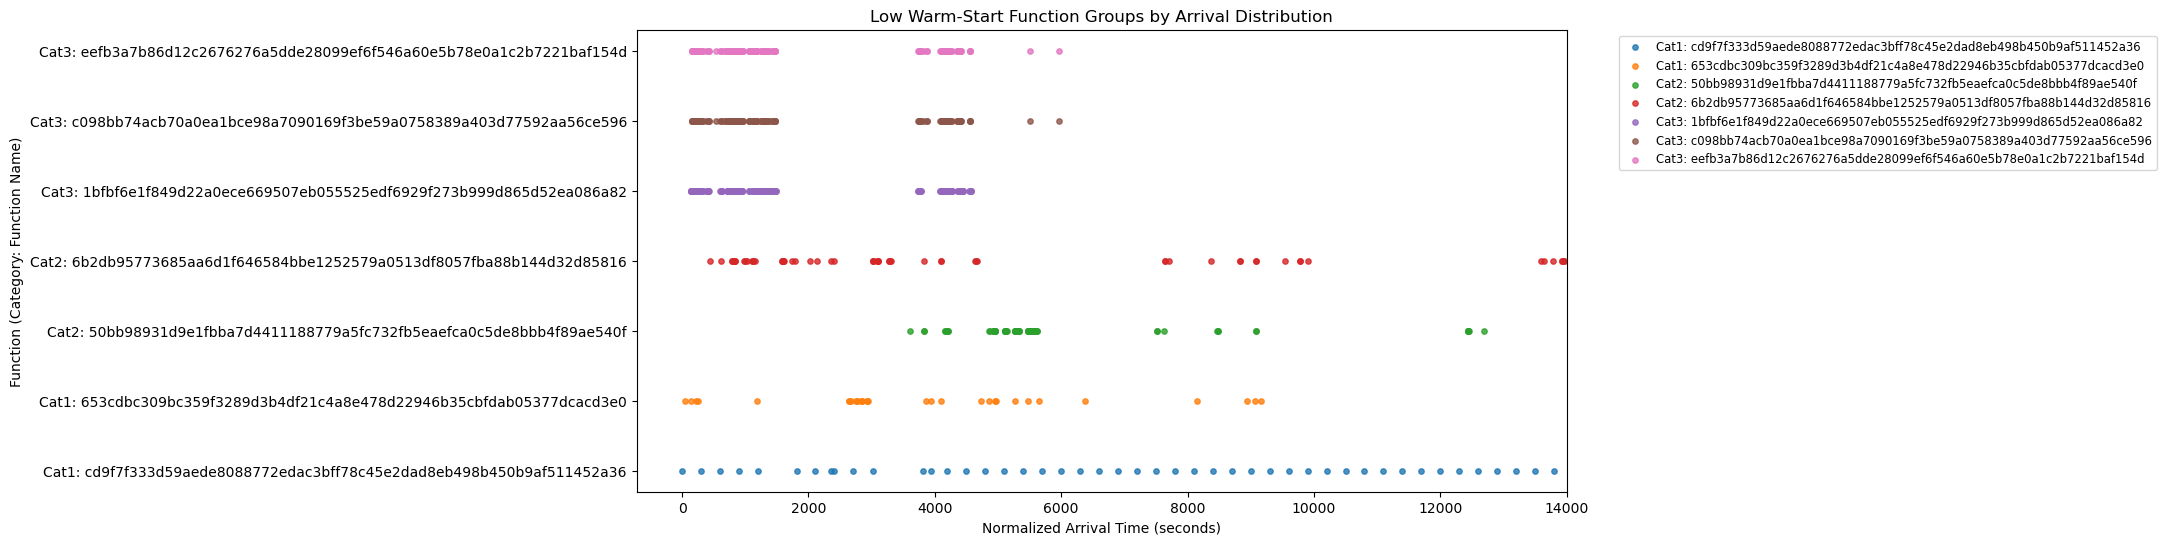

In [122]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

all_funcs = []
all_func_colors = {}
colors = plt.cm.tab10.colors
color_idx = 0

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    cat = entry['category']
    # if cat != 3:
    #     continue
    funcs = entry['functions']
    cat_color = colors[cat % len(colors)]
    for func in funcs:
        func_label = f"Cat{cat}: {func}"
        all_funcs.append(func_label)
        all_func_colors[func_label] = colors[color_idx % len(colors)]
        color_idx += 1
        func_df = df[(df['trace_id'] == trace_id) & (df['func'] == func)]
        plt.scatter(
            func_df['arrival_time_norm'],
            [func_label] * len(func_df),
            s=15,
            color=all_func_colors[func_label],
            label=func_label,
            alpha=0.8
        )


# Optional: Set max x-axis range
plt.xlim(right=14000)

# Deduplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.xlabel("Normalized Arrival Time (seconds)")
plt.ylabel("Function (Category: Function Name)")
plt.title("Low Warm-Start Function Groups by Arrival Distribution")
plt.tight_layout()
plt.show()


In [123]:
data = ['alexnet', 'efficientnet', 'bert', 'distilgpt2', 'resnet50', 'googlenet', 'inception']
i = 0 
res = []
name_header = ['func','trace_id','category_id','id','memory','file_path']
for l in best_groups:
    total_subset = len(l['functions'])
    
    for k in range(0,total_subset):
        temp = []
        trace_id = l['trace_id']
        category_id = l['category']
        func = data[i]
        memory = 1024
        file_path = data[i]+".py"
        id_val = l['functions'][k]
        i += 1
        res.append([func, trace_id, category_id, id_val, memory, file_path])

res_df = pd.DataFrame(res,columns=name_header)
func_dict = res_df.set_index('id')['func'].to_dict()
func_dict

{'cd9f7f333d59aede8088772edac3bff78c45e2dad8eb498b450b9af511452a36': 'alexnet',
 '653cdbc309bc359f3289d3b4df21c4a8e478d22946b35cbfdab05377dcacd3e0': 'efficientnet',
 '50bb98931d9e1fbba7d4411188779a5fc732fb5eaefca0c5de8bbb4f89ae540f': 'bert',
 '6b2db95773685aa6d1f646584bbe1252579a0513df8057fba88b144d32d85816': 'distilgpt2',
 '1bfbf6e1f849d22a0ece669507eb055525edf6929f273b999d865d52ea086a82': 'resnet50',
 'c098bb74acb70a0ea1bce98a7090169f3be59a0758389a403d77592aa56ce596': 'googlenet',
 'eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78e0a1c2b7221baf154d': 'inception'}

In [124]:
best_df_list = []

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    funcs = entry['functions']
    filtered = df[(df['trace_id'] == trace_id) & (df['func'].isin(funcs))]
    best_df_list.append(filtered)

# Concatenate all the filtered DataFrames
best_df = pd.concat(best_df_list, ignore_index=True)

# Optional: Sort by trace_id and arrival_time_norm for convenience
best_df = best_df.sort_values(by=['trace_id', 'func', 'arrival_time_norm']).reset_index(drop=True)

# Corrected normalization of arrival_time (if needed again)
best_df['arrival_time'] = best_df['arrival_time_norm']




In [125]:
best_df['func_id'] = best_df['func'].map(func_dict)
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id
0,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,5.184469e+05,1.684,45.195146,36,45.195146,efficientnet
1,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,5.185476e+05,2.222,145.402876,36,145.402876,efficientnet
2,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,5.186222e+05,2.256,219.955671,36,219.955671,efficientnet
3,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,5.186593e+05,1.953,257.305680,36,257.305680,efficientnet
4,c8c43e1a911f29e5506460a2fbef61ff39723d672f3b3b...,653cdbc309bc359f3289d3b4df21c4a8e478d22946b35c...,5.195822e+05,2.972,1179.197593,36,1179.197593,efficientnet
...,...,...,...,...,...,...,...,...
853,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,1.026959e+06,0.000,4559.382860,71,4559.382860,inception
854,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,1.026960e+06,0.000,4560.329884,71,4560.329884,inception
855,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,1.026961e+06,0.000,4561.332361,71,4561.332361,inception
856,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,1.027899e+06,0.000,5498.928761,71,5498.928761,inception


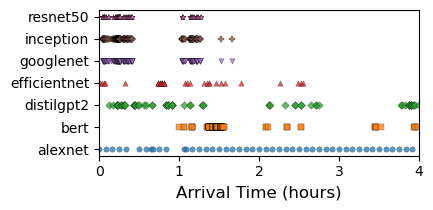

In [129]:
import matplotlib.pyplot as plt
import itertools

# Convert seconds to hours for x-axis
best_df['arrival_time_hr'] = best_df['arrival_time'] / 3600.0

# Marker styles to cycle through
markers = itertools.cycle(('o', 's', 'D', '^', 'v', 'P', '*'))

plt.figure(figsize=(4.5, 2.2))

# Plot each function group with style
for func_id, group in best_df.groupby('func_id'):
    plt.scatter(
        group['arrival_time_hr'],
        [func_id]*len(group),
        s=15,
        alpha=0.75,
        marker=next(markers),
        edgecolors='k',
        linewidths=0.2
    )

plt.xlabel("Arrival Time (hours)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 4)
# plt.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.savefig("graphs_images/cold_dataset_graph.png", dpi=300, bbox_inches='tight')
plt.show()

In [130]:
category_counts = best_df['func_id'].value_counts().sort_index()
category_counts

func_id
alexnet          47
bert            100
distilgpt2       71
efficientnet     32
googlenet       195
inception       195
resnet50        218
Name: count, dtype: int64

In [131]:
res_df.to_csv('../dataset/cold_gen_functions.csv', index=False)
best_df.to_csv('../dataset/cold_gen_df.csv', index=False)